# StyleGAN Training Visualization

Visualizing training statistics for StyleGAN2-ADA training on corrosion dataset.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## Load Training Statistics

In [2]:
# Define paths
base_path = Path('../logs/stylegan2ada/corrosion/00001-stylegan2-corrosion_512x512-gpus1-batch8-gamma6.5536')
stats_file = base_path / 'stats.jsonl'
fid_file = base_path / 'metric-fid50k_full.jsonl'
kid_file = base_path / 'metric-kid50k_full.jsonl'

# Load stats.jsonl
stats_data = []
with open(stats_file, 'r') as f:
    for line in f:
        stats_data.append(json.loads(line))

print(f"Loaded {len(stats_data)} training snapshots")

# Extract kimg values (handle nested dict structure)
kimg_vals = []
for entry in stats_data:
    if 'Progress/kimg' in entry:
        val = entry['Progress/kimg']
        if isinstance(val, dict):
            kimg_vals.append(val['mean'])
        else:
            kimg_vals.append(val)

if kimg_vals:
    print(f"Training progress: {kimg_vals[-1]:.2f} kimg")

# Load FID scores
fid_data = []
with open(fid_file, 'r') as f:
    for line in f:
        fid_data.append(json.loads(line))

fid_df = pd.DataFrame(fid_data)
fid_df['kimg'] = fid_df['snapshot_pkl'].str.extract(r'(\d+)').astype(int) * 4 / 1000  # Convert to kimg

# Load KID scores
kid_data = []
with open(kid_file, 'r') as f:
    for line in f:
        kid_data.append(json.loads(line))

kid_df = pd.DataFrame(kid_data)
kid_df['kimg'] = kid_df['snapshot_pkl'].str.extract(r'(\d+)').astype(int) * 4 / 1000  # Convert to kimg

print(f"\nFID scores: {len(fid_df)} evaluations")
print(f"KID scores: {len(kid_df)} evaluations")

Loaded 1116 training snapshots
Training progress: 4460.01 kimg

FID scores: 112 evaluations
KID scores: 112 evaluations


## Loss Metrics Over Time

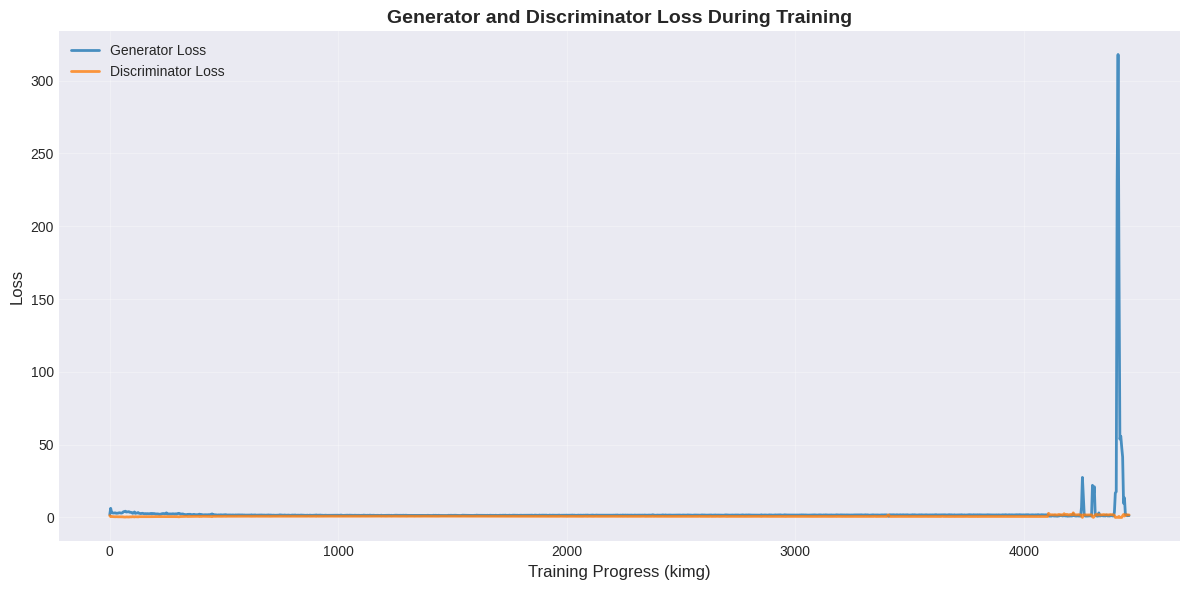

Final G Loss: 1.2226
Final D Loss: 1.7391


In [3]:
# Ensure kimg_vals is properly extracted (in case cell 4 wasn't run after the fix)
if kimg_vals and isinstance(kimg_vals[0], dict):
    kimg_vals = []
    for entry in stats_data:
        if 'Progress/kimg' in entry:
            val = entry['Progress/kimg']
            if isinstance(val, dict):
                kimg_vals.append(val['mean'])
            else:
                kimg_vals.append(val)

# Extract loss data
g_loss = [entry['Loss/G/loss']['mean'] for entry in stats_data if 'Loss/G/loss' in entry]
d_loss = [entry['Loss/D/loss']['mean'] for entry in stats_data if 'Loss/D/loss' in entry]

# Plot Generator and Discriminator Loss
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.plot(kimg_vals[:len(g_loss)], g_loss, label='Generator Loss', linewidth=2, alpha=0.8)
ax.plot(kimg_vals[:len(d_loss)], d_loss, label='Discriminator Loss', linewidth=2, alpha=0.8)
ax.set_xlabel('Training Progress (kimg)', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Generator and Discriminator Loss During Training', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final G Loss: {g_loss[-1]:.4f}")
print(f"Final D Loss: {d_loss[-1]:.4f}")

## Scores and Regularization

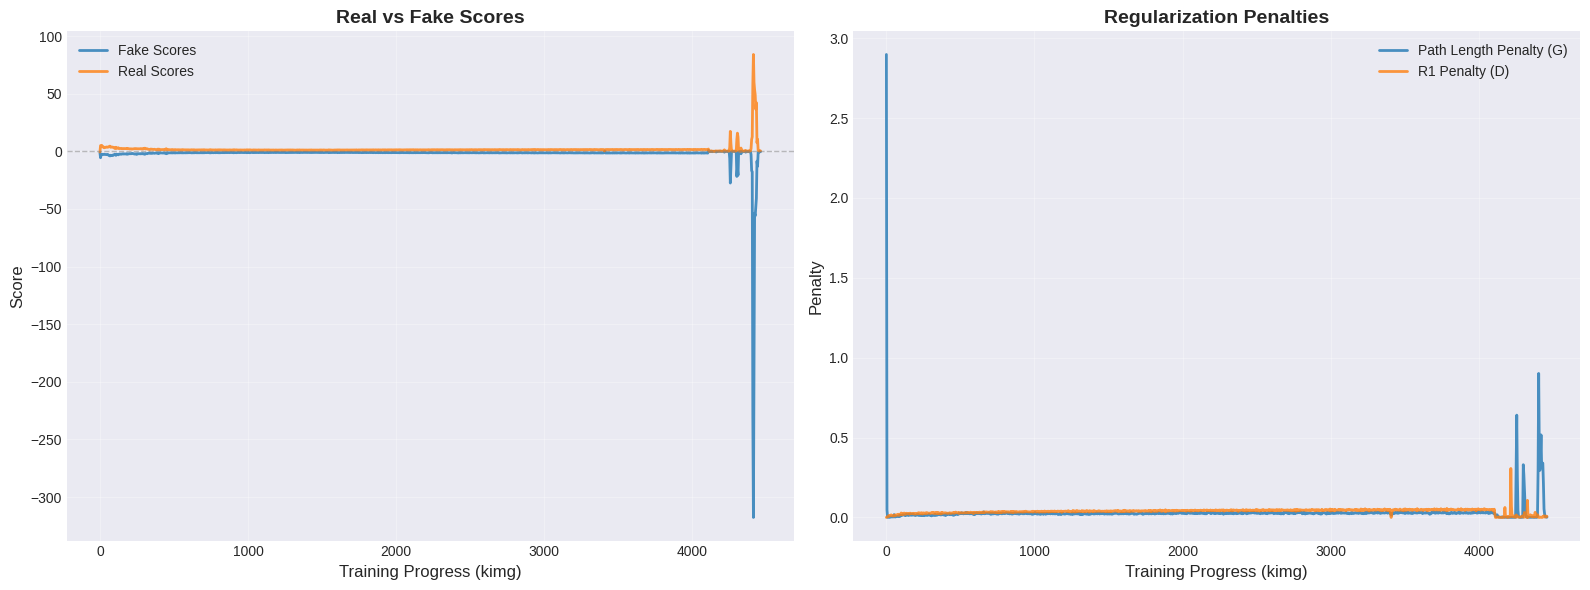

In [4]:
# Extract score data
scores_fake = [entry['Loss/scores/fake']['mean'] for entry in stats_data if 'Loss/scores/fake' in entry]
scores_real = [entry['Loss/scores/real']['mean'] for entry in stats_data if 'Loss/scores/real' in entry]

# Extract regularization data
pl_penalty = [entry['Loss/pl_penalty']['mean'] for entry in stats_data if 'Loss/pl_penalty' in entry]
r1_penalty = [entry['Loss/r1_penalty']['mean'] for entry in stats_data if 'Loss/r1_penalty' in entry]

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot scores
axes[0].plot(kimg_vals[:len(scores_fake)], scores_fake, label='Fake Scores', linewidth=2, alpha=0.8)
axes[0].plot(kimg_vals[:len(scores_real)], scores_real, label='Real Scores', linewidth=2, alpha=0.8)
axes[0].axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_xlabel('Training Progress (kimg)', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Real vs Fake Scores', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot penalties
axes[1].plot(kimg_vals[:len(pl_penalty)], pl_penalty, label='Path Length Penalty (G)', linewidth=2, alpha=0.8)
axes[1].plot(kimg_vals[:len(r1_penalty)], r1_penalty, label='R1 Penalty (D)', linewidth=2, alpha=0.8)
axes[1].set_xlabel('Training Progress (kimg)', fontsize=12)
axes[1].set_ylabel('Penalty', fontsize=12)
axes[1].set_title('Regularization Penalties', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## FID and KID Quality Metrics

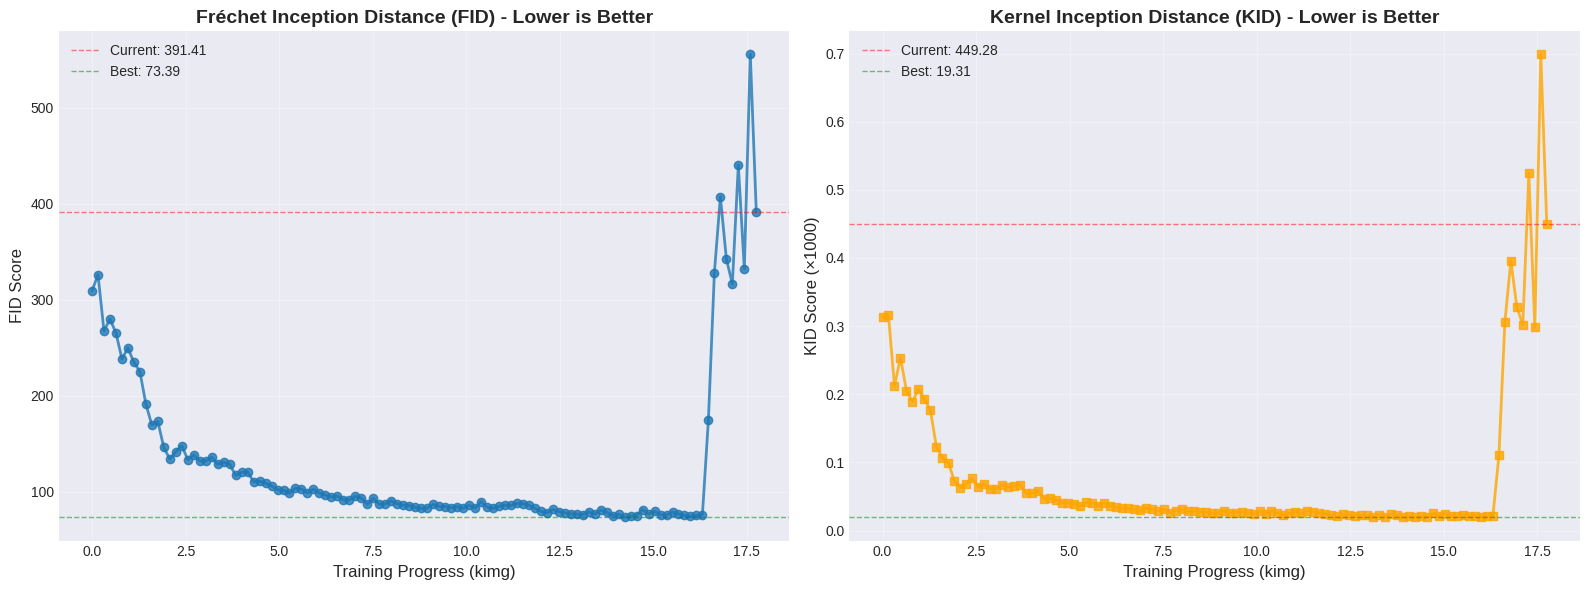


FID Score - Best: 73.39, Current: 391.41
KID Score - Best: 19.31, Current: 449.28


In [5]:
# Create subplots for FID and KID
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot FID
fid_scores = [d['results']['fid50k_full'] for d in fid_data]
axes[0].plot(fid_df['kimg'], fid_scores, marker='o', linewidth=2, markersize=6, alpha=0.8)
axes[0].set_xlabel('Training Progress (kimg)', fontsize=12)
axes[0].set_ylabel('FID Score', fontsize=12)
axes[0].set_title('Fréchet Inception Distance (FID) - Lower is Better', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=fid_scores[-1], color='red', linestyle='--', linewidth=1, alpha=0.5, 
                label=f'Current: {fid_scores[-1]:.2f}')
axes[0].axhline(y=min(fid_scores), color='green', linestyle='--', linewidth=1, alpha=0.5, 
                label=f'Best: {min(fid_scores):.2f}')
axes[0].legend(fontsize=10)

# Plot KID
kid_scores = [d['results']['kid50k_full'] for d in kid_data]
axes[1].plot(kid_df['kimg'], kid_scores, marker='s', linewidth=2, markersize=6, alpha=0.8, color='orange')
axes[1].set_xlabel('Training Progress (kimg)', fontsize=12)
axes[1].set_ylabel('KID Score (×1000)', fontsize=12)
axes[1].set_title('Kernel Inception Distance (KID) - Lower is Better', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=kid_scores[-1], color='red', linestyle='--', linewidth=1, alpha=0.5, 
                label=f'Current: {kid_scores[-1]*1000:.2f}')
axes[1].axhline(y=min(kid_scores), color='green', linestyle='--', linewidth=1, alpha=0.5, 
                label=f'Best: {min(kid_scores)*1000:.2f}')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nFID Score - Best: {min(fid_scores):.2f}, Current: {fid_scores[-1]:.2f}")
print(f"KID Score - Best: {min(kid_scores)*1000:.2f}, Current: {kid_scores[-1]*1000:.2f}")

## Training Resource Usage

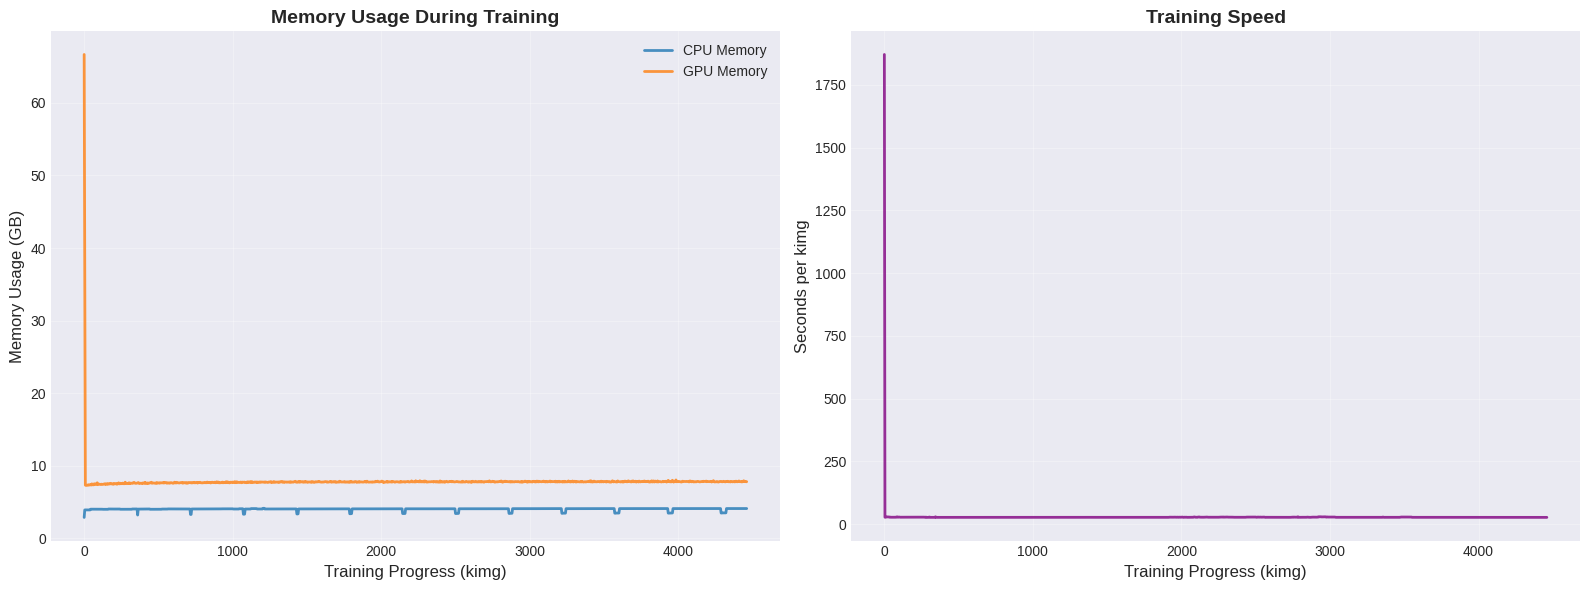


Average GPU Memory: 7.84 GB
Average Training Speed: 28.91 sec/kimg


In [6]:
# Extract timing and resource data (handle nested dict structure)
cpu_mem = []
gpu_mem = []
sec_per_kimg = []

for entry in stats_data:
    if 'Resources/cpu_mem_gb' in entry:
        val = entry['Resources/cpu_mem_gb']
        cpu_mem.append(val['mean'] if isinstance(val, dict) else val)
    
    if 'Resources/peak_gpu_mem_gb' in entry:
        val = entry['Resources/peak_gpu_mem_gb']
        gpu_mem.append(val['mean'] if isinstance(val, dict) else val)
    
    if 'Timing/sec_per_kimg' in entry:
        val = entry['Timing/sec_per_kimg']
        sec_per_kimg.append(val['mean'] if isinstance(val, dict) else val)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot memory usage
axes[0].plot(kimg_vals[:len(cpu_mem)], cpu_mem, label='CPU Memory', linewidth=2, alpha=0.8)
axes[0].plot(kimg_vals[:len(gpu_mem)], gpu_mem, label='GPU Memory', linewidth=2, alpha=0.8)
axes[0].set_xlabel('Training Progress (kimg)', fontsize=12)
axes[0].set_ylabel('Memory Usage (GB)', fontsize=12)
axes[0].set_title('Memory Usage During Training', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot training speed
axes[1].plot(kimg_vals[:len(sec_per_kimg)], sec_per_kimg, linewidth=2, alpha=0.8, color='purple')
axes[1].set_xlabel('Training Progress (kimg)', fontsize=12)
axes[1].set_ylabel('Seconds per kimg', fontsize=12)
axes[1].set_title('Training Speed', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nAverage GPU Memory: {np.mean(gpu_mem):.2f} GB")
print(f"Average Training Speed: {np.mean(sec_per_kimg):.2f} sec/kimg")

## Overall Training Summary Dashboard

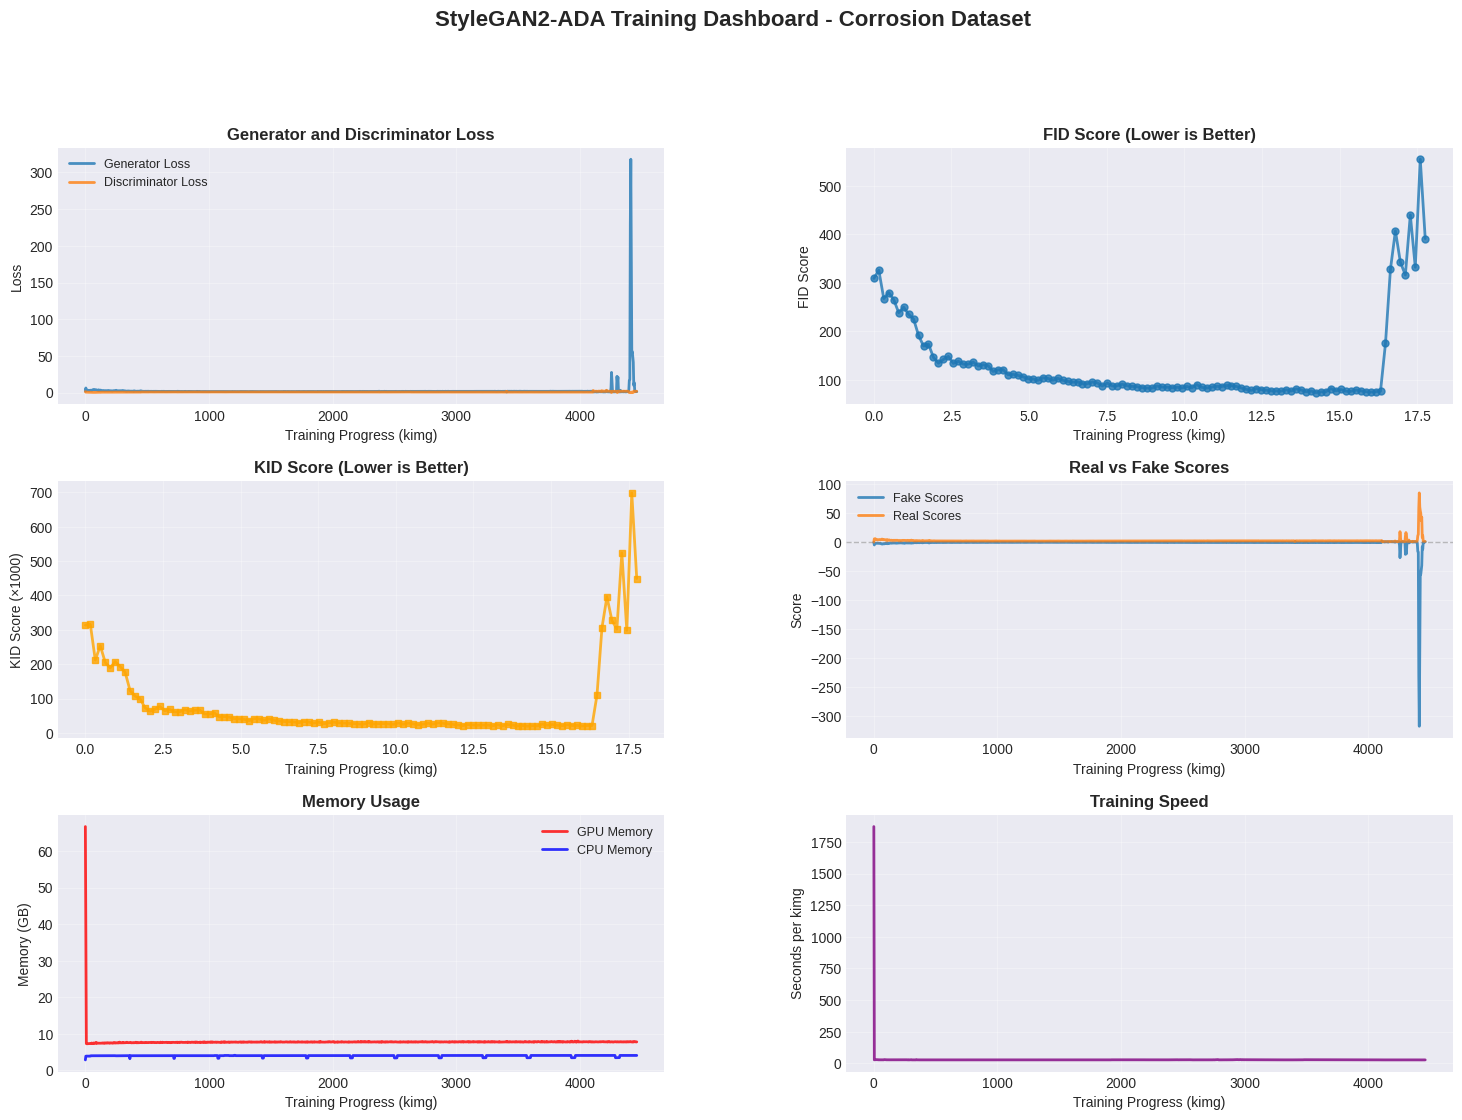

TRAINING SUMMARY
Total Training Progress: 4460.01 kimg
Total Training Time: 42.52 hours (1.77 days)

Final Losses:
  Generator Loss: 1.2226
  Discriminator Loss: 1.7391

Quality Metrics:
  Best FID: 73.39 (at 14 kimg)
  Current FID: 391.41
  Best KID: 19.31 (at 14 kimg)
  Current KID: 449.28

Resource Usage:
  Average GPU Memory: 7.84 GB
  Peak GPU Memory: 66.67 GB
  Average Training Speed: 28.91 sec/kimg


In [7]:
# Extract timing values for summary (handle nested dict structure)
total_hours = []
total_days = []
for entry in stats_data:
    if 'Timing/total_hours' in entry:
        val = entry['Timing/total_hours']
        total_hours.append(val['mean'] if isinstance(val, dict) else val)
    if 'Timing/total_days' in entry:
        val = entry['Timing/total_days']
        total_days.append(val['mean'] if isinstance(val, dict) else val)

# Create comprehensive dashboard
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Loss curves
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(kimg_vals[:len(g_loss)], g_loss, label='Generator Loss', linewidth=2, alpha=0.8)
ax1.plot(kimg_vals[:len(d_loss)], d_loss, label='Discriminator Loss', linewidth=2, alpha=0.8)
ax1.set_xlabel('Training Progress (kimg)', fontsize=10)
ax1.set_ylabel('Loss', fontsize=10)
ax1.set_title('Generator and Discriminator Loss', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# 2. FID score
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(fid_df['kimg'], fid_scores, marker='o', linewidth=2, markersize=5, alpha=0.8)
ax2.set_xlabel('Training Progress (kimg)', fontsize=10)
ax2.set_ylabel('FID Score', fontsize=10)
ax2.set_title('FID Score (Lower is Better)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. KID score
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(kid_df['kimg'], np.array(kid_scores) * 1000, marker='s', linewidth=2, markersize=5, alpha=0.8, color='orange')
ax3.set_xlabel('Training Progress (kimg)', fontsize=10)
ax3.set_ylabel('KID Score (×1000)', fontsize=10)
ax3.set_title('KID Score (Lower is Better)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# 4. Scores (real vs fake)
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(kimg_vals[:len(scores_fake)], scores_fake, label='Fake Scores', linewidth=2, alpha=0.8)
ax4.plot(kimg_vals[:len(scores_real)], scores_real, label='Real Scores', linewidth=2, alpha=0.8)
ax4.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax4.set_xlabel('Training Progress (kimg)', fontsize=10)
ax4.set_ylabel('Score', fontsize=10)
ax4.set_title('Real vs Fake Scores', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

# 5. Memory usage
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(kimg_vals[:len(gpu_mem)], gpu_mem, label='GPU Memory', linewidth=2, alpha=0.8, color='red')
ax5.plot(kimg_vals[:len(cpu_mem)], cpu_mem, label='CPU Memory', linewidth=2, alpha=0.8, color='blue')
ax5.set_xlabel('Training Progress (kimg)', fontsize=10)
ax5.set_ylabel('Memory (GB)', fontsize=10)
ax5.set_title('Memory Usage', fontsize=12, fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)

# 6. Training speed
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(kimg_vals[:len(sec_per_kimg)], sec_per_kimg, linewidth=2, alpha=0.8, color='purple')
ax6.set_xlabel('Training Progress (kimg)', fontsize=10)
ax6.set_ylabel('Seconds per kimg', fontsize=10)
ax6.set_title('Training Speed', fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.3)

plt.suptitle('StyleGAN2-ADA Training Dashboard - Corrosion Dataset', fontsize=16, fontweight='bold', y=0.995)
plt.show()

# Print summary statistics
print("=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)
print(f"Total Training Progress: {kimg_vals[-1]:.2f} kimg")
if total_hours and total_days:
    print(f"Total Training Time: {total_hours[-1]:.2f} hours ({total_days[-1]:.2f} days)")
print(f"\nFinal Losses:")
print(f"  Generator Loss: {g_loss[-1]:.4f}")
print(f"  Discriminator Loss: {d_loss[-1]:.4f}")
print(f"\nQuality Metrics:")
print(f"  Best FID: {min(fid_scores):.2f} (at {fid_df['kimg'].iloc[np.argmin(fid_scores)]:.0f} kimg)")
print(f"  Current FID: {fid_scores[-1]:.2f}")
print(f"  Best KID: {min(kid_scores)*1000:.2f} (at {kid_df['kimg'].iloc[np.argmin(kid_scores)]:.0f} kimg)")
print(f"  Current KID: {kid_scores[-1]*1000:.2f}")
print(f"\nResource Usage:")
print(f"  Average GPU Memory: {np.mean(gpu_mem):.2f} GB")
print(f"  Peak GPU Memory: {max(gpu_mem):.2f} GB")
print(f"  Average Training Speed: {np.mean(sec_per_kimg):.2f} sec/kimg")
print("=" * 60)